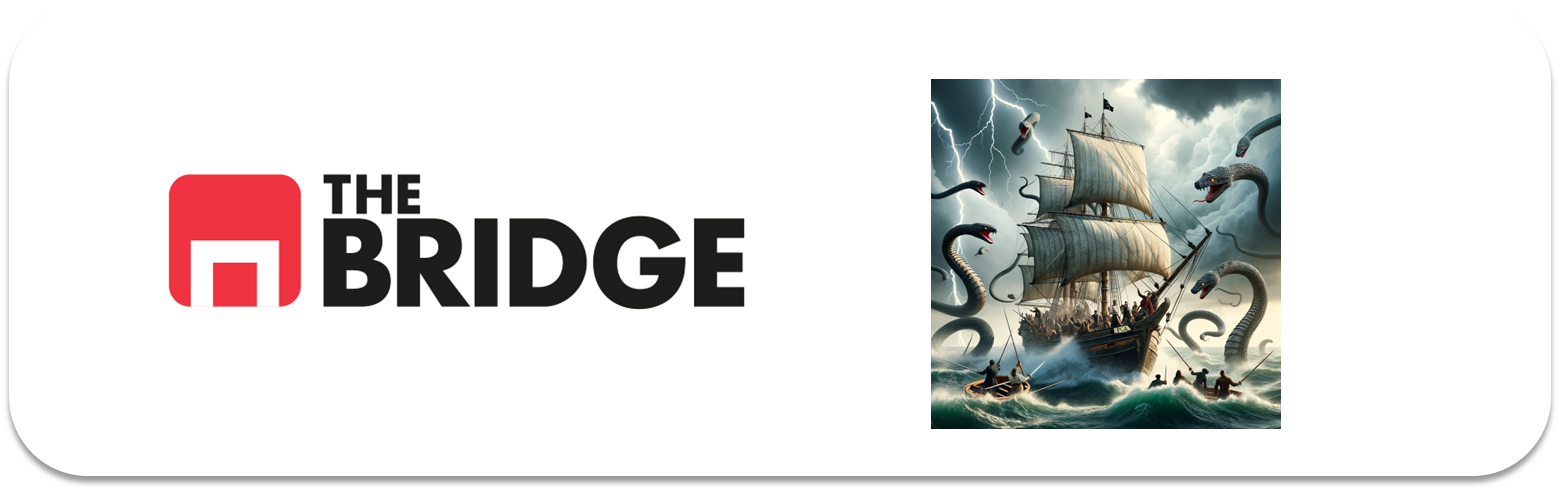

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado y split
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Selección de features
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    SelectFromModel, RFE, SequentialFeatureSelector
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas
from sklearn.metrics import balanced_accuracy_score, classification_report

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df = pd.read_csv('data/credit_npo.csv')
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [6]:
df.shape

(12537, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [7]:
# Eliminamos las filas que tengan algún valor nulo en cualquier columna
df = df.dropna()

print(df.shape)

(11816, 11)


In [8]:
# Columnas que empiezan por "NumberOf" o similares con conteos
cols_number = ['NumberOfTime30-59DaysPastDueNotWorse', 
               'NumberOfOpenCreditLinesAndLoans',
               'NumberOfTimes90DaysLate', 
               'NumberRealEstateLoansOrLines',
               'NumberOfTime60-89DaysPastDueNotWorse', 
               'NumberOfDependents']

for col in cols_number:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index())
    print()

--- NumberOfTime30-59DaysPastDueNotWorse ---
NumberOfTime30-59DaysPastDueNotWorse
0     9818
1     1354
2      397
3      127
4       64
5       23
6       20
7        1
8        2
98      10
Name: count, dtype: int64

--- NumberOfOpenCreditLinesAndLoans ---
NumberOfOpenCreditLinesAndLoans
0      112
1      307
2      445
3      638
4      848
5      963
6     1031
7     1110
8     1009
9      965
10     765
11     719
12     574
13     454
14     365
15     338
16     236
17     216
18     151
19     129
20     118
21      62
22      61
23      39
24      38
25      30
26      19
27      16
28      13
29      10
30      10
31       7
32       3
33       4
34       2
35       2
36       1
38       1
40       1
41       1
43       1
48       1
49       1
Name: count, dtype: int64

--- NumberOfTimes90DaysLate ---
NumberOfTimes90DaysLate
0     11156
1       394
2       142
3        54
4        31
5        14
6         6
7         3
8         3
9         1
10        1
13        1
98       

In [9]:
# Función para categorizar en 3 niveles: 0 / 1-2 / 3+
# Cualquier valor >=3 (incluidos los códigos centinela como 98) cae en "3+"
def categorizar_3niveles(valor):
    if valor == 0:
        return '0'
    elif valor in [1, 2]:
        return '1-2'
    else:
        return '3+'

# Columnas que vamos a categorizar con este esquema
cols_categorizar = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

# Aplicamos la función a cada columna, creando una nueva columna "_cat"
for col in cols_categorizar:
    df[col + '_cat'] = df[col].apply(categorizar_3niveles)

# Comprobamos el resultado para una de ellas
df[['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime30-59DaysPastDueNotWorse_cat']].head(10)

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime30-59DaysPastDueNotWorse_cat
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [10]:
# Verificamos los conteos de la columna categórica para confirmar los 3 niveles
df['NumberOfTime30-59DaysPastDueNotWorse_cat'].value_counts()

NumberOfTime30-59DaysPastDueNotWorse_cat
0      9818
1-2    1751
3+      247
Name: count, dtype: int64

In [11]:
# Verificamos los conteos para las demás columnas categorizadas
for col in cols_categorizar:
    print(f"--- {col}_cat ---")
    print(df[col + '_cat'].value_counts())
    print()

--- NumberOfTime30-59DaysPastDueNotWorse_cat ---
NumberOfTime30-59DaysPastDueNotWorse_cat
0      9818
1-2    1751
3+      247
Name: count, dtype: int64

--- NumberOfTime60-89DaysPastDueNotWorse_cat ---
NumberOfTime60-89DaysPastDueNotWorse_cat
0      11206
1-2      563
3+        47
Name: count, dtype: int64

--- NumberOfTimes90DaysLate_cat ---
NumberOfTimes90DaysLate_cat
0      11156
1-2      536
3+       124
Name: count, dtype: int64

--- NumberRealEstateLoansOrLines_cat ---
NumberRealEstateLoansOrLines_cat
1-2    6734
0      4233
3+      849
Name: count, dtype: int64

--- NumberOfDependents_cat ---
NumberOfDependents_cat
0      6413
1-2    4182
3+     1221
Name: count, dtype: int64



In [12]:
# Columnas numéricas "puras" que no hemos categorizado
cols_numericas = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 
                   'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

# Comprobamos que están todas en el DataFrame
print(df[cols_numericas].describe())

       RevolvingUtilizationOfUnsecuredLines           age     DebtRatio  \
count                          11816.000000  11816.000000  11816.000000   
mean                               0.335668     51.447698      0.499708   
std                                0.365209     14.516270      2.696067   
min                                0.000000     21.000000      0.000000   
25%                                0.034927     41.000000      0.143456   
50%                                0.179183     51.000000      0.294748   
75%                                0.587187     62.000000      0.477414   
max                                6.000000    101.000000     96.000000   

       MonthlyIncome  NumberOfOpenCreditLinesAndLoans  
count   11816.000000                     11816.000000  
mean     6864.815420                         8.759140  
std     11855.905437                         5.129772  
min         0.000000                         0.000000  
25%      3498.750000                        

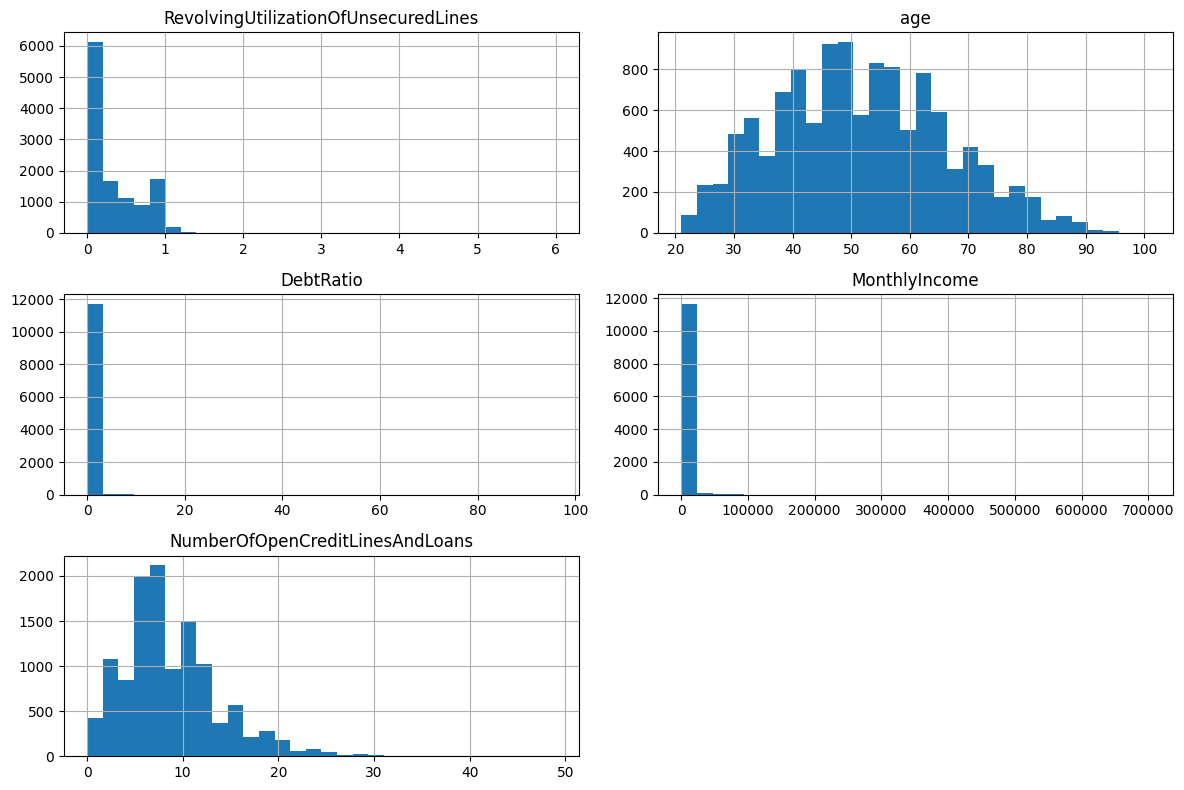

In [14]:
# Histogramas de las 5 numéricas para ver su distribución de un vistazo
df[cols_numericas].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

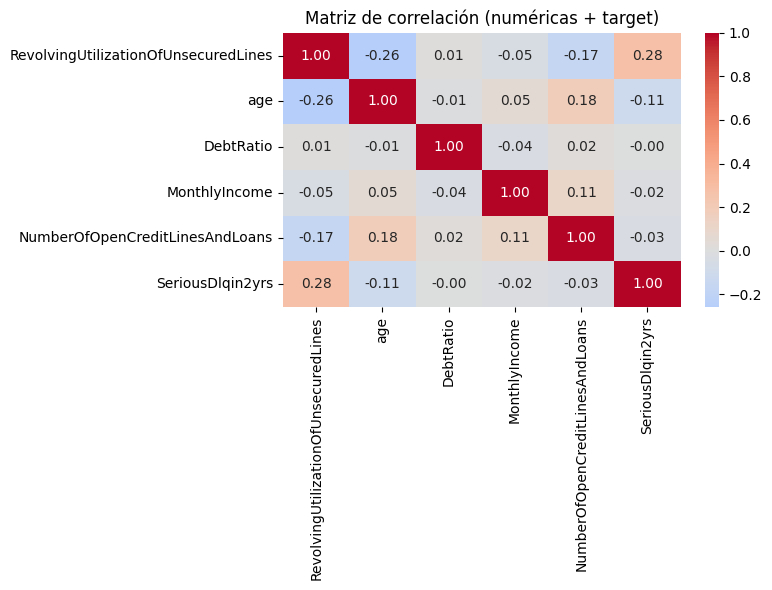

In [15]:
# Matriz de correlación entre las numéricas y el target
# Incluimos el target para ver qué tan relacionada está cada feature con él
cols_corr = cols_numericas + ['SeriousDlqin2yrs']

matriz_corr = df[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (numéricas + target)')
plt.tight_layout()
plt.show()

## Interpretación: análisis visual y correlación

Los histogramas muestran que DebtRatio y MonthlyIncome tienen outliers extremos (valores como 96 o 702500) que distorsionan la visualización, aplastando la distribución real contra el cero. RevolvingUtilizationOfUnsecuredLines, age y NumberOfOpenCreditLinesAndLoans sí muestran formas de distribución reconocibles.

En la matriz de correlación con el target, destaca claramente RevolvingUtilizationOfUnsecuredLines (0.28), seguida de age (-0.11) de forma más débil. El resto de variables numéricas (DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans) muestran correlación prácticamente nula con el target (entre -0.03 y 0.02).

En cuanto a covarianza entre features, no se observan correlaciones altas entre pares (la máxima es -0.26 entre RevolvingUtilizationOfUnsecuredLines y age), por lo que no hay redundancia clara que justifique eliminar alguna variable por este motivo.

**Lista "primera división" de este paso (filtrado por correlación):** RevolvingUtilizationOfUnsecuredLines, age, NumberOfOpenCreditLinesAndLoans (las 3 con mayor relación con el target, aunque solo las dos primeras tienen correlación relevante; incluimos la tercera para completar el análisis con las disponibles, dado el bajo número de numéricas puras).

In [16]:
# Variables numéricas puras (sin categorizar)
cols_numericas = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 
                   'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']

# Variables categóricas (las que creamos en el paso 1)
cols_categoricas = [
    'NumberOfTime30-59DaysPastDueNotWorse_cat',
    'NumberOfTime60-89DaysPastDueNotWorse_cat',
    'NumberOfTimes90DaysLate_cat',
    'NumberRealEstateLoansOrLines_cat',
    'NumberOfDependents_cat'
]

# Target
y = df['SeriousDlqin2yrs']

print(f"Numéricas: {len(cols_numericas)}, Categóricas: {len(cols_categoricas)}")

Numéricas: 5, Categóricas: 5


In [17]:
# X solo con las numéricas
X_num = df[cols_numericas]

# SelectKBest con f_classif (ANOVA): k='all' para ver el ranking completo de todas,
# así decidimos nosotros mismos el corte en vez de fijarlo a ciegas
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_num, y)

# Construimos un DataFrame con el resultado, ordenado de mayor a menor score
resultado_anova = pd.DataFrame({
    'feature': cols_numericas,
    'score_anova': selector_anova.scores_,
    'p_value': selector_anova.pvalues_
}).sort_values('score_anova', ascending=False)

print(resultado_anova)

                                feature  score_anova        p_value
0  RevolvingUtilizationOfUnsecuredLines  1007.740824  2.652100e-212
1                                   age   134.446536   6.413858e-31
4       NumberOfOpenCreditLinesAndLoans    10.341763   1.304037e-03
3                         MonthlyIncome     5.824786   1.581701e-02
2                             DebtRatio     0.032798   8.562901e-01


In [18]:
# Las categóricas hay que codificarlas a números antes de pasarlas a mutual_info_classif
# Usamos un mapeo simple ya que son ordinales (0 < 1-2 < 3+)
mapeo_ordinal = {'0': 0, '1-2': 1, '3+': 2}

X_cat = df[cols_categoricas].apply(lambda col: col.map(mapeo_ordinal))

# Calculamos mutual information; discrete_features=True porque son categóricas
mi_scores = mutual_info_classif(X_cat, y, discrete_features=True, random_state=42)

resultado_mi = pd.DataFrame({
    'feature': cols_categoricas,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print(resultado_mi)

                                    feature  mutual_info
2               NumberOfTimes90DaysLate_cat     0.034220
0  NumberOfTime30-59DaysPastDueNotWorse_cat     0.022352
1  NumberOfTime60-89DaysPastDueNotWorse_cat     0.019231
3          NumberRealEstateLoansOrLines_cat     0.001583
4                    NumberOfDependents_cat     0.001030


## Interpretación: SelectKBest/ANOVA y Mutual Information

**ANOVA (numéricas):** RevolvingUtilizationOfUnsecuredLines domina con un score muchísimo más alto que el resto (1007 vs 134 de age), confirmando lo visto en el heatmap de correlación. NumberOfOpenCreditLinesAndLoans y MonthlyIncome aportan algo, aunque mucho menos. DebtRatio tiene un p-value de 0.86, es decir, no hay evidencia estadística de relación con el target — se descarta.

**Mutual Information (categóricas):** las tres variables relacionadas con impagos pasados (90DaysLate, 30-59Days, 60-89Days) muestran mayor información mutua con el target que NumberRealEstateLoansOrLines y NumberOfDependents, que son casi irrelevantes (valores cercanos a 0).

**Lista "primera división" de este paso:** RevolvingUtilizationOfUnsecuredLines, age, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate_cat, NumberOfTime30-59DaysPastDueNotWorse_cat, NumberOfTime60-89DaysPastDueNotWorse_cat (las 3 numéricas con mejor score de ANOVA + las 3 categóricas con mejor mutual information)

In [19]:
# Codificamos las categóricas igual que antes (mapeo ordinal)
# y juntamos con las numéricas en un único X
X_completo = df[cols_numericas + cols_categoricas].copy()
X_completo[cols_categoricas] = X_completo[cols_categoricas].apply(lambda col: col.map(mapeo_ordinal))

print(X_completo.shape)
X_completo.head()

(11816, 10)


,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTime30-59DaysPastDueNotWorse_cat,NumberOfTime60-89DaysPastDueNotWorse_cat,NumberOfTimes90DaysLate_cat,NumberRealEstateLoansOrLines_cat,NumberOfDependents_cat
0,0.081892,37,0.070709,5656.0,12,0,0,1,0,0
1,0.023413,74,0.209197,4870.0,9,0,0,0,1,0
2,0.000000,43,0.080784,5000.0,2,0,0,0,0,1
3,0.492754,44,0.412735,7333.0,4,0,0,0,1,2
4,1.000000,63,0.000000,8333.0,3,0,0,0,0,1


In [21]:
# Usamos un RandomForest como modelo intermedio: nos da feature_importances_
# directamente, es robusto a escalas distintas y captura relaciones no lineales
modelo_intermedio = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# max_features=6 limita a las 6 más importantes como mucho (el límite del enunciado)
selector_sfm = SelectFromModel(modelo_intermedio, max_features=6, threshold=-np.inf)
selector_sfm.fit(X_completo, y)

# Vemos qué features fueron seleccionadas
features_sfm = X_completo.columns[selector_sfm.get_support()].tolist()
print("Features seleccionadas:", features_sfm)

Features seleccionadas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat']


In [22]:
importancias = pd.DataFrame({
    'feature': X_completo.columns,
    'importancia': selector_sfm.estimator_.feature_importances_
}).sort_values('importancia', ascending=False)

print(importancias)

                                    feature  importancia
0      RevolvingUtilizationOfUnsecuredLines     0.205255
2                                 DebtRatio     0.168793
3                             MonthlyIncome     0.163043
1                                       age     0.128445
4           NumberOfOpenCreditLinesAndLoans     0.103530
7               NumberOfTimes90DaysLate_cat     0.096880
5  NumberOfTime30-59DaysPastDueNotWorse_cat     0.038535
6  NumberOfTime60-89DaysPastDueNotWorse_cat     0.037994
9                    NumberOfDependents_cat     0.035171
8          NumberRealEstateLoansOrLines_cat     0.022353


## Interpretación: SelectFromModel (RandomForest)

A diferencia de ANOVA y Mutual Information (que evalúan cada feature de forma aislada), SelectFromModel con un RandomForest considera todas las features juntas y puede capturar relaciones no lineales. Esto explica que DebtRatio y MonthlyIncome aparezcan aquí como relativamente importantes (0.17 y 0.16), pese a tener correlación lineal casi nula con el target en el análisis de correlación y ANOVA.

RevolvingUtilizationOfUnsecuredLines se mantiene como la feature más importante, consistente con los pasos anteriores.

**Lista "primera división" de este paso:** RevolvingUtilizationOfUnsecuredLines, age, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate_cat (las 6 con mayor importancia según el RandomForest).

In [23]:
# Usamos RandomForest también aquí, para mantener consistencia con el paso anterior
# y porque ya vimos que captura relaciones que ANOVA no detecta
modelo_rfe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# n_features_to_select=6: nos quedamos con el máximo que permite el enunciado
# step=1: en cada iteración elimina 1 sola feature (más preciso, aunque más lento)
selector_rfe = RFE(estimator=modelo_rfe, n_features_to_select=6, step=1)
selector_rfe.fit(X_completo, y)

# Features seleccionadas (las que sobrevivieron al proceso de eliminación)
features_rfe = X_completo.columns[selector_rfe.support_].tolist()
print("Features seleccionadas:", features_rfe)

# El ranking: 1 = seleccionada, 2 = primera eliminada, 3 = segunda eliminada, etc.
ranking_rfe = pd.DataFrame({
    'feature': X_completo.columns,
    'ranking': selector_rfe.ranking_
}).sort_values('ranking')

print(ranking_rfe)

Features seleccionadas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat']
                                    feature  ranking
0      RevolvingUtilizationOfUnsecuredLines        1
1                                       age        1
2                                 DebtRatio        1
3                             MonthlyIncome        1
4           NumberOfOpenCreditLinesAndLoans        1
7               NumberOfTimes90DaysLate_cat        1
5  NumberOfTime30-59DaysPastDueNotWorse_cat        2
6  NumberOfTime60-89DaysPastDueNotWorse_cat        3
9                    NumberOfDependents_cat        4
8          NumberRealEstateLoansOrLines_cat        5


## Interpretación: RFE

RFE selecciona exactamente las mismas 6 features que SelectFromModel: RevolvingUtilizationOfUnsecuredLines, age, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans y NumberOfTimes90DaysLate_cat. Esta coincidencia tiene sentido porque ambos métodos usan RandomForest como modelo base.

El ranking del resto de features muestra el orden de eliminación: NumberOfTime30-59DaysPastDueNotWorse_cat fue la primera en descartarse, seguida de NumberOfTime60-89DaysPastDueNotWorse_cat, NumberOfDependents_cat, y por último NumberRealEstateLoansOrLines_cat como la menos relevante de todas.

**Lista "primera división" de este paso:** RevolvingUtilizationOfUnsecuredLines, age, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate_cat.

In [24]:
# Modelo base: usamos LogisticRegression aquí en vez de RandomForest,
# para variar el tipo de modelo entre técnicas y no depender siempre del mismo
# (SFS es más lento, así que un modelo más simple ayuda a que no tarde demasiado)
modelo_sfs = LogisticRegression(max_iter=1000, random_state=42)

# direction='forward': empieza vacío y va añadiendo features
# n_features_to_select=6: el máximo que permite el enunciado
# cv=5: usa validación cruzada de 5 folds para decidir qué feature añadir en cada paso
selector_sfs = SequentialFeatureSelector(
    modelo_sfs, 
    n_features_to_select=6, 
    direction='forward', 
    cv=5,
    n_jobs=-1
)
selector_sfs.fit(X_completo, y)

# Features seleccionadas
features_sfs = X_completo.columns[selector_sfs.get_support()].tolist()
print("Features seleccionadas:", features_sfs)

Features seleccionadas: ['DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTimes90DaysLate_cat', 'NumberRealEstateLoansOrLines_cat']


## Interpretación: SFS (Sequential Feature Selector)

SFS selecciona un conjunto distinto a RFE y SelectFromModel: DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTime30-59DaysPastDueNotWorse_cat, NumberOfTimes90DaysLate_cat y NumberRealEstateLoansOrLines_cat. Llama la atención que no incluya RevolvingUtilizationOfUnsecuredLines ni age, pese a ser las features con mayor correlación individual con el target.

Esto se explica por dos factores: SFS usa LogisticRegression (modelo lineal) en vez de RandomForest, y al construir el conjunto de forma incremental evaluando el rendimiento conjunto (no la importancia individual), puede preferir combinaciones de variables menos redundantes entre sí en lugar de las dos más fuertes individualmente si estas se solapan en la información que aportan.

**Lista "primera división" de este paso:** DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTime30-59DaysPastDueNotWorse_cat, NumberOfTimes90DaysLate_cat, NumberRealEstateLoansOrLines_cat.

In [25]:
# Juntamos las 5 listas de features seleccionadas en cada paso anterior
listas_seleccion = {
    'correlacion': ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans'],
    'anova_mi': ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans',
                 'NumberOfTimes90DaysLate_cat', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 
                 'NumberOfTime60-89DaysPastDueNotWorse_cat'],
    'select_from_model': features_sfm,
    'rfe': features_rfe,
    'sfs': features_sfs
}

# Contamos cuántas veces aparece cada feature en el conjunto de las 5 listas
from collections import Counter

todas_las_features_votadas = []
for lista in listas_seleccion.values():
    todas_las_features_votadas.extend(lista)

conteo_votos = Counter(todas_las_features_votadas)

# Lo pasamos a DataFrame ordenado de más a menos votado
df_votos = pd.DataFrame(conteo_votos.items(), columns=['feature', 'votos']).sort_values('votos', ascending=False)
print(df_votos)

                                    feature  votos
2           NumberOfOpenCreditLinesAndLoans      5
0      RevolvingUtilizationOfUnsecuredLines      4
1                                       age      4
3               NumberOfTimes90DaysLate_cat      4
6                                 DebtRatio      3
7                             MonthlyIncome      3
4  NumberOfTime30-59DaysPastDueNotWorse_cat      2
5  NumberOfTime60-89DaysPastDueNotWorse_cat      1
8          NumberRealEstateLoansOrLines_cat      1


In [26]:
# Nos quedamos con las 6 features más votadas
features_hardvoting = df_votos.head(6)['feature'].tolist()
print("Features por hard-voting:", features_hardvoting)

Features por hard-voting: ['NumberOfOpenCreditLinesAndLoans', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTimes90DaysLate_cat', 'DebtRatio', 'MonthlyIncome']


## Interpretación: Hard-voting

Combinando las 5 técnicas anteriores por número de votos, las 6 features más consistentes son: NumberOfOpenCreditLinesAndLoans (5/5 técnicas), RevolvingUtilizationOfUnsecuredLines, age y NumberOfTimes90DaysLate_cat (4/5 cada una), y DebtRatio y MonthlyIncome (3/5 cada una). Hay un corte natural y sin empates entre estas 6 (mínimo 3 votos) y la siguiente feature en la lista (2 votos), lo que da confianza en que esta selección final es robusta y no depende de un único criterio.

**Lista "primera división" final (hard-voting):** NumberOfOpenCreditLinesAndLoans, RevolvingUtilizationOfUnsecuredLines, age, NumberOfTimes90DaysLate_cat, DebtRatio, MonthlyIncome.

In [27]:
# Preparamos X (todas las features disponibles, ya numéricas+categóricas codificadas) e y
X = X_completo  # ya lo tenemos construido del paso 2.3
y = df['SeriousDlqin2yrs']

# Split 80/20, estratificado porque el target probablemente está desbalanceado
# (en problemas de morosidad suele haber muchos más "0" que "1")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))  # vemos el balance de clases

(9452, 10) (2364, 10)
SeriousDlqin2yrs
0    0.92975
1    0.07025
Name: proportion, dtype: float64


In [28]:
from sklearn.ensemble import GradientBoostingClassifier

# Diccionario con los 3 modelos a comparar
modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

In [29]:
# Reunimos las 6 listas de features en un diccionario para iterar fácilmente
listas_features_final = {
    'correlacion': ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans'],
    'anova_mi': ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans',
                 'NumberOfTimes90DaysLate_cat', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 
                 'NumberOfTime60-89DaysPastDueNotWorse_cat'],
    'select_from_model': features_sfm,
    'rfe': features_rfe,
    'sfs': features_sfs,
    'hard_voting': features_hardvoting
}

# Lista para acumular los 18 resultados
resultados_paso3 = []

# Bucle anidado: para cada modelo, para cada lista de features
for nombre_modelo, modelo in modelos.items():
    for nombre_lista, features in listas_features_final.items():
        
        # Nos quedamos solo con las columnas de esta lista de features
        X_train_subset = X_train[features]
        
        # Validación cruzada con 5 folds, balanced_accuracy como métrica
        cv_scores = cross_val_score(
            modelo, X_train_subset, y_train, 
            cv=5, scoring='balanced_accuracy'
        )
        
        # Guardamos el resultado de esta combinación
        resultados_paso3.append({
            'modelo': nombre_modelo,
            'lista_features': nombre_lista,
            'n_features': len(features),
            'balanced_accuracy_cv': cv_scores.mean(),
            'std_cv': cv_scores.std()
        })

# Convertimos a DataFrame y ordenamos de mejor a peor
df_resultados_paso3 = pd.DataFrame(resultados_paso3).sort_values('balanced_accuracy_cv', ascending=False)
print(df_resultados_paso3.to_string())

                modelo     lista_features  n_features  balanced_accuracy_cv    std_cv
13    GradientBoosting           anova_mi           6              0.599493  0.013163
11        RandomForest        hard_voting           6              0.597243  0.003589
9         RandomForest                rfe           6              0.593313  0.010448
8         RandomForest  select_from_model           6              0.593313  0.010448
7         RandomForest           anova_mi           6              0.592776  0.015761
15    GradientBoosting                rfe           6              0.592578  0.008030
14    GradientBoosting  select_from_model           6              0.592578  0.008030
17    GradientBoosting        hard_voting           6              0.592578  0.008030
1   LogisticRegression           anova_mi           6              0.585047  0.008743
10        RandomForest                sfs           6              0.582299  0.013217
16    GradientBoosting                sfs           6 

## Interpretación: comparativa de 18 combinaciones (3 modelos × 6 listas)

GradientBoosting con la lista anova_mi obtiene el mejor balanced_accuracy en cross-validation (0.5995), seguido muy de cerca por RandomForest con hard_voting (0.5972). Las diferencias entre los primeros puestos son pequeñas, lo que sugiere que varias combinaciones son razonablemente competitivas.

La lista basada solo en correlación queda última en los tres modelos, confirmando que las variables de impagos pasados (descartadas en esa lista por ser categóricas) aportan información valiosa que el filtrado de correlación simple no pudo capturar.

LogisticRegression rinde sistemáticamente peor que RandomForest y GradientBoosting en casi todas las listas, lo que sugiere que existen relaciones no lineales en los datos que el modelo lineal no logra capturar tan bien.

Los scores en general son moderados (0.50-0.60), reflejando la dificultad del problema: predecir morosidad grave con un dataset muy desbalanceado (93%/7%) y un número reducido de features.

**Modelo y lista de features elegidos:** GradientBoosting con la lista anova_mi (RevolvingUtilizationOfUnsecuredLines, age, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate_cat, NumberOfTime30-59DaysPastDueNotWorse_cat, NumberOfTime60-89DaysPastDueNotWorse_cat).

In [30]:
# Nos quedamos solo con las 6 features de la lista ganadora (anova_mi)
features_finales = listas_features_final['anova_mi']

X_train_final = X_train[features_finales]
X_test_final = X_test[features_finales]

print(X_train_final.columns.tolist())

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTime60-89DaysPastDueNotWorse_cat']


In [31]:
# Definimos una rejilla de hiperparámetros razonable para GradientBoosting
param_grid = {
    'n_estimators': [100, 200],          # número de árboles
    'learning_rate': [0.05, 0.1],        # qué tanto corrige cada árbol al anterior
    'max_depth': [2, 3, 4],              # profundidad máxima de cada árbol
    'min_samples_leaf': [10, 20]         # mínimo de muestras por hoja, evita overfitting
}

modelo_base = GradientBoostingClassifier(random_state=42)

# GridSearchCV con la misma métrica (balanced_accuracy) y mismo cv=5 que usamos antes,
# para que el resultado sea comparable con lo visto en el Paso 3
grid_search = GridSearchCV(
    modelo_base,
    param_grid,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor balanced_accuracy en CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 10, 'n_estimators': 200}
Mejor balanced_accuracy en CV: 0.6062


In [32]:
# Nos quedamos con el mejor modelo encontrado por GridSearchCV
mejor_modelo = grid_search.best_estimator_

# Predecimos sobre test
y_pred_test = mejor_modelo.predict(X_test_final)

# Calculamos balanced accuracy en test
test_score_final = balanced_accuracy_score(y_test, y_pred_test)

print(f"Balanced accuracy en test: {test_score_final:.4f}")
print()
print(classification_report(y_test, y_pred_test))

Balanced accuracy en test: 0.6009

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2198
           1       0.52      0.22      0.31       166

    accuracy                           0.93      2364
   macro avg       0.73      0.60      0.64      2364
weighted avg       0.91      0.93      0.92      2364



## Interpretación: optimización de hiperparámetros y evaluación final

GridSearchCV mejora el balanced_accuracy en CV de 0.5995 (parámetros por defecto) a 0.6062, con los hiperparámetros learning_rate=0.1, max_depth=4, min_samples_leaf=10 y n_estimators=200 — un ajuste que favorece árboles algo más profundos y un mayor número de estimadores, compensado con regularización vía min_samples_leaf.

En test, el modelo obtiene un balanced_accuracy de 0.6009, muy cercano al de CV, lo que indica que no hay sobreajuste y el modelo generaliza de forma consistente.

El classification_report muestra la dificultad real del problema: para la clase mayoritaria (no moroso) el modelo funciona muy bien (recall 0.98), pero para la clase minoritaria (moroso grave, la que más interesa detectar en un caso de negocio real) el recall es bajo (0.22), reflejando lo limitado de la señal predictiva disponible con solo 6 features y un fuerte desbalanceo de clases (93%/7%).

**Conclusión final:** El modelo seleccionado (GradientBoosting optimizado, con la lista de features anova_mi: RevolvingUtilizationOfUnsecuredLines, age, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate_cat, NumberOfTime30-59DaysPastDueNotWorse_cat, NumberOfTime60-89DaysPastDueNotWorse_cat) logra un balanced_accuracy de 0.60 en test. Aunque modesto en términos absolutos, supera claramente al azar (0.50) y demuestra que, de las 6 técnicas de selección de features probadas, anova_mi ofrece el mejor equilibrio entre simplicidad (6 variables) y poder predictivo.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

In [34]:
from sklearn.decomposition import PCA

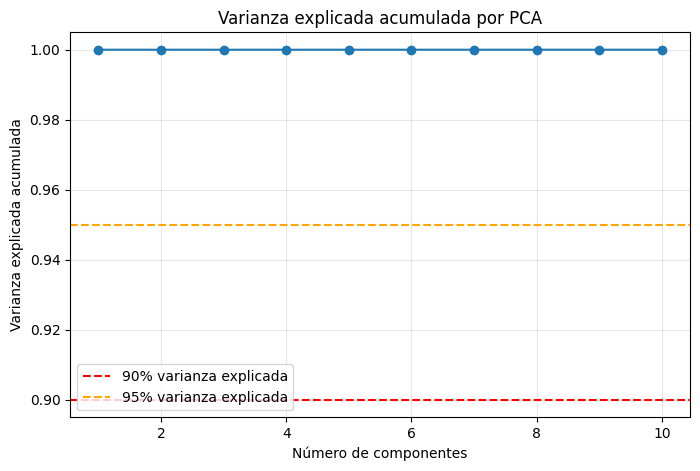

[0.99999849 0.99999979 0.99999995 0.99999999 1.         1.
 1.         1.         1.         1.        ]


In [35]:
# Aplicamos PCA sin fijar n_components, sobre TODAS las features disponibles
# (no solo las 6 de la lista ganadora, ya que PCA funciona mejor aprovechando
# toda la información disponible para construir sus combinaciones)
pca_extra = PCA(random_state=42)
pca_extra.fit(X_train)

# Varianza explicada acumulada por cada número de componentes
varianza_acumulada = np.cumsum(pca_extra.explained_variance_ratio_)

# Visualizamos para decidir el corte
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% varianza explicada')
plt.axhline(0.95, color='orange', linestyle='--', label='95% varianza explicada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(varianza_acumulada)

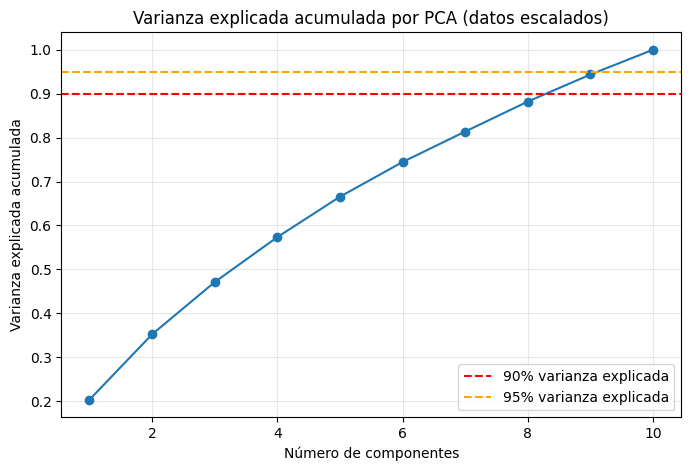

[0.20341197 0.3522568  0.47115506 0.57342767 0.66547909 0.74441878
 0.81381503 0.88204805 0.94362024 1.        ]


In [36]:
from sklearn.preprocessing import StandardScaler

# Escalamos las features: StandardScaler las deja con media 0 y desviación 1
# Esto es imprescindible antes de PCA cuando las features tienen escalas muy distintas
# (ajustamos el scaler SOLO con X_train, para no filtrar información de test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Repetimos el PCA, ahora sobre los datos escalados
pca_extra = PCA(random_state=42)
pca_extra.fit(X_train_scaled)

varianza_acumulada = np.cumsum(pca_extra.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% varianza explicada')
plt.axhline(0.95, color='orange', linestyle='--', label='95% varianza explicada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada por PCA (datos escalados)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(varianza_acumulada)

In [37]:
# Aplicamos PCA con 9 componentes sobre los datos ya escalados
pca_final = PCA(n_components=9, random_state=42)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print(X_train_pca.shape, X_test_pca.shape)

(9452, 9) (2364, 9)


In [38]:
# Entrenamos el MISMO modelo ganador del Paso 3/4: GradientBoosting
# con los hiperparámetros optimizados por GridSearchCV
modelo_pca = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=4,
    min_samples_leaf=10,
    n_estimators=200,
    random_state=42
)

# Validación cruzada sobre train, igual que hicimos para las 6 listas del Paso 3
cv_scores_pca = cross_val_score(
    modelo_pca, X_train_pca, y_train,
    cv=5, scoring='balanced_accuracy'
)

print(f"Balanced accuracy en CV (PCA, 9 comp): {cv_scores_pca.mean():.4f}")

# Entrenamos en todo train y evaluamos contra test
modelo_pca.fit(X_train_pca, y_train)
y_pred_pca = modelo_pca.predict(X_test_pca)
test_score_pca = balanced_accuracy_score(y_test, y_pred_pca)

print(f"Balanced accuracy en test (PCA, 9 comp): {test_score_pca:.4f}")

Balanced accuracy en CV (PCA, 9 comp): 0.5887
Balanced accuracy en test (PCA, 9 comp): 0.6077


## Interpretación: PCA como método de selección

Al aplicar PCA directamente sobre las 10 features originales (sin escalar), una sola componente capturaba el 99.99% de la varianza — un resultado engañoso causado por la enorme diferencia de escala entre variables como MonthlyIncome (hasta 700.000) y RevolvingUtilizationOfUnsecuredLines (entre 0 y 6). Tras escalar los datos con StandardScaler, la curva de varianza explicada se vuelve gradual y realista, necesitando 9 de las 10 componentes para superar el 90% de varianza explicada (94.4% exactamente). Esto refleja que las features originales ya tenían relativamente poca redundancia entre sí (consistente con la baja correlación observada en el heatmap del Paso 2.1), por lo que PCA apenas puede comprimir el dataset en este caso.

Entrenando el mismo modelo ganador (GradientBoosting con los hiperparámetros optimizados) sobre los datos transformados por PCA, se obtiene un balanced_accuracy de 0.5887 en CV y 0.6077 en test. Comparado con la selección de features (anova_mi: 0.6062 CV / 0.6009 test), los resultados son muy similares, con diferencias menores a 2 puntos en ambas direcciones.

**Conclusión:** Para este dataset, PCA no aporta una ventaja clara sobre la selección de features tradicional, ni en rendimiento ni en compresión (necesita 9 de 10 componentes). Además, PCA tiene la desventaja de perder la interpretabilidad de las variables originales (cada componente es una combinación de todas las features), algo especialmente relevante en un problema de credit scoring donde la explicabilidad del modelo suele ser un requisito de negocio. Por tanto, se mantiene la recomendación de usar la selección de features (lista anova_mi) como enfoque preferido.